In [ ]:
import sys
sys.path.append("..")
from cavsim3d.cavsim3d import *
from cavsim3d.geometry import *

# define geometry
filepath = fr'C:\Users\Soske\Documents\git_projects\cavsim2d\rect_split_test.stp'
rwg = ModelImport(filepath, 'mm')
rwg.add_plane([(-0.075, -0.050, 0), (0.075, 0.050, 0)])
# rwg.add_plane([(-0.075, -0.050, -0.1), (0.075, 0.050, -0.1)])
# rwg.add_plane([(-0.075, -0.050, 0.1), (0.075, 0.050, 0.1)])
rwg.split()
rwg.view()

In [ ]:
compstruct = CompoundStructure(rwg)
compstruct.prepare()

# Concatenation

In [ ]:
concat = Concat(compstruct)
# concat.glue_geo()
connections = [
    (('cell_1', "port2"), ('cell_2', "port1")),
    # ((s2, "port2"), (s3, "port1"))
]
concat.build_matrices()
Xs = concat.solve_FD(1, 4, 100)
romres = concat.rom()
concat.check_eigs_system(concat.Ac)
concat.check_eigs_system(concat.Ard)

Zfull = concat.zfull(1, 4, 100)
Zred = concat.zreduced(1, 4, 1000)


In [ ]:
# get analytic solution for concatenated geometry
a, L, maxh = 100e-3, 400e-3, 0.04
rwg = RWG(a, L, maxh)
rwg_analytical = RWGAnalytic(rwg)
rwg_analytical.solve_FD(1, 4, 1000)

In [ ]:
# plot solutions
%matplotlib widget

ax = rwg_analytical.plot_analytical()
ax = concat.plotZ('reduced', ax)
ax = concat.plotZ('full', ax)

In [1]:
from cavsim3d.core.em_project import EMProject
from cavsim3d.geometry.primitives import CircularWaveguide

# Initialize project and assembly
proj = EMProject(name='cwg_concat_example', overwrite=True)
assembly = proj.create_assembly(main_axis='Z')

# Create two segments
radius, L = 50e-3, 100e-3
wg1 = CircularWaveguide(radius=radius, length=L)
wg2 = CircularWaveguide(radius=radius, length=L)

# Add and align sequentially
assembly.add("segment1", wg1)
assembly.add("segment2", wg2, after="segment1")
assembly.build()

# Visualize the geometry
assembly.show() 

# Generate and visualize the mesh
assembly.generate_mesh(maxh=0.03)
assembly.show('mesh')

Creating new project 'cwg_concat_example' at c:\Users\Soske\Documents\git_projects\cavsim3d\notebooks\cwg_concat_example
Port naming complete:
  Total ports: 3
  External ports: 2
  Interface ports: 1


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': 'Netgen x.x', 'mesh_dim': …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [4]:
# Solve subdomains from 2.0 to 3.0 GHz (above cutoff)
fom_config = {
    'nportmodes': 3,
    'order': 3,
    'fmin': 1e-3,
    'fmax': 3.0,
    'nsamples': 30,
    'solver_type': 'direct',
    # 'verbose': True
}
fom_result = proj.fds.solve(config=fom_config)

  Returning cached results. (Use rerun=True to force recompute)


In [5]:
# Reduce subdomains via POD
roms = proj.fds.foms.reduce(tol=1e-6)

# Concatenate into a unified system and solve on more sample points
concat = roms.concatenate()
concat_result = concat.solve(fmin=1e-3, fmax=3.0, nsamples=1000)


Model Order Reduction
Reduction complete: 11588 → 57 DOFs (99.5% compression)
Saved port modes to c:\Users\Soske\Documents\git_projects\cavsim3d\notebooks\cwg_concat_example\fds\port_modes\port_modes.pkl

Concat Solve: 0.001 - 3.0 GHz, 1000 samples, system size 54
  Concat solve complete: 0.017s (1000 frequencies)


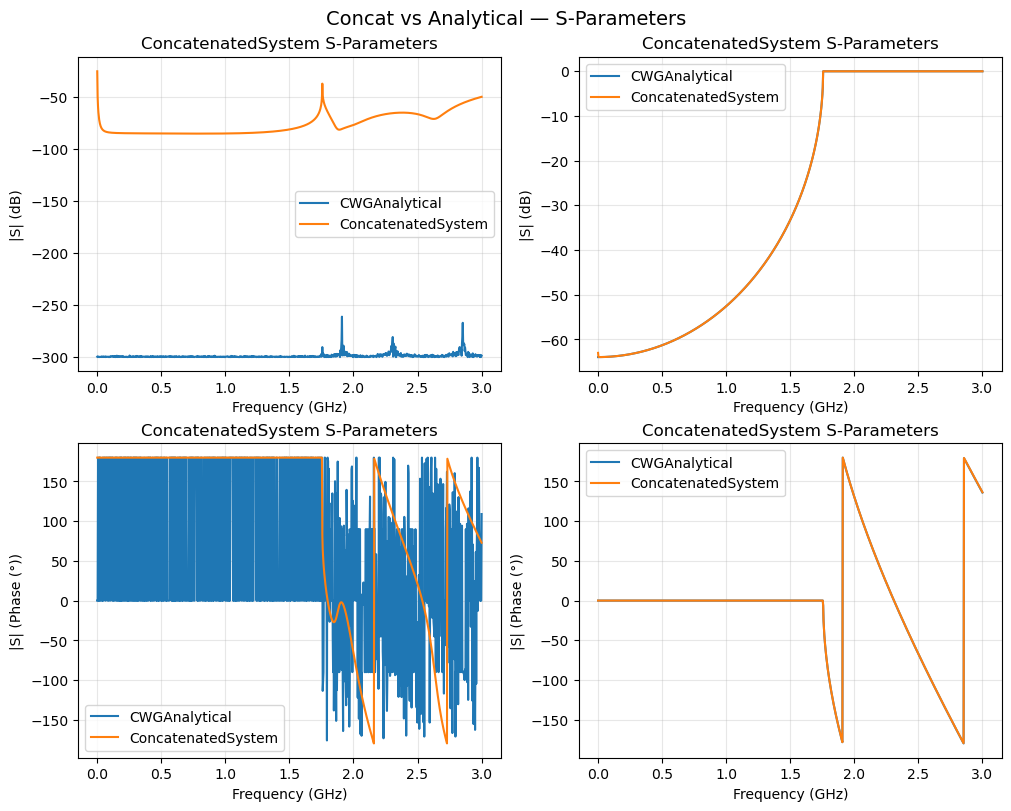

In [8]:
from cavsim3d.analytical.circular_waveguide import CWGAnalytical
import matplotlib.pyplot as plt

# [Snippet 1] Compare with Analytical Solution
analytical = CWGAnalytical(radius=radius, length=2 * L, 
                            freq_range=(fom_config['fmin'], fom_config['fmax']))

# Visualize comparison
which = [['1(1)1(1)'], ['1(1)2(1)']]

fig, axs = plt.subplot_mosaic(
    [[1, 2], [3, 4]], figsize=(10, 8), layout='constrained'
)

for idx, wh in enumerate(which):
    # Magnitude
    analytical.plot_s(wh, ax=axs[idx + 1])
    concat.plot_s(wh, ax=axs[idx + 1])
    # Phase
    analytical.plot_s(wh, plot_type='phase', ax=axs[idx + 3])
    concat.plot_s(wh, plot_type='phase', ax=axs[idx + 3])

fig.suptitle('Concat vs Analytical — S-Parameters', fontsize=14)
plt.show()

In [23]:
import numpy as np
# Compute the eigenmodes of the concatenated ROM
evals, evecs = concat.get_eigenmodes()
freqs = np.sqrt(evals)/(2*np.pi) * 1e-9
print(freqs)
# Plot the 3D field pattern of the an eigenmode
concat.plot_eigenmode(6)

[1.63941565e-07 2.16495806e-07 3.62708740e-06 3.74252433e-06
 3.82428135e-06 6.21683240e-06 1.75696353e+00 1.75697542e+00
 1.91016907e+00 1.91019103e+00 2.30975850e+00 2.30979856e+00
 2.41422079e+00 2.74133919e+00 2.85457855e+00 2.85473518e+00
 2.91620215e+00 2.91622322e+00 2.91686445e+00 3.21407363e+00
 3.47622922e+00 3.47704694e+00 3.77928227e+00 4.14863594e+00
 4.15018725e+00 4.40444448e+00 4.85181111e+00 4.85242157e+00
 5.06853231e+00 5.58146917e+00 5.58307224e+00 5.77745236e+00
 6.48752917e+00 6.49803513e+00 6.65214699e+00 7.31749041e+00
 7.33707704e+00 7.41571446e+00 8.09859611e+00 8.15905880e+00
 8.18396942e+00 9.90801850e+00 9.93311092e+00 1.01216336e+01
 1.49779517e+01 1.50010766e+01 1.57226164e+01 1.57363026e+01
 1.64371251e+01 1.70350428e+01 1.74031025e+01 1.75845805e+01
 1.90128848e+01]


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'euler_angles': […